## Basic Pitch on PianoVAM

Imports

In [ ]:
from pathlib import Path
from huggingface_hub import snapshot_download
import json
import time
import contextlib
import io

import matplotlib.pyplot as plt
import mir_eval
import numpy as np
import pandas as pd

from basic_pitch import ICASSP_2022_MODEL_PATH
from basic_pitch.inference import predict
from evaluation_function.compare_MIDI import compare_performance_ED

Download dataset

In [2]:
# Directory where the PianoVAM dataset will be stored
DATA_ROOT = Path("data/PianoVAM_v1")

if DATA_ROOT.exists():
    print("PianoVAM dataset already exists.")
else:
    print("Downloading PianoVAM dataset...")
    snapshot_download(
        repo_id="PianoVAM/PianoVAM_v1",
        repo_type="dataset",
        local_dir=DATA_ROOT,
        allow_patterns=[
            "Audio/**",
            "MIDI/**",
            "TSV/**",
            "metadata.json",
            "README.md",
        ],
    )
    print("Download complete.")

PianoVAM dataset already exists.


Configuration

In [3]:
# PianoVAM paths
AUDIO_DIR = DATA_ROOT / "Audio"
MIDI_DIR = DATA_ROOT / "MIDI"
TSV_DIR = DATA_ROOT / "TSV"
METADATA_PATH = DATA_ROOT / "metadata.json"

# Output path
OUTPUT_DIR = Path("outputs/phase2_baseline")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Basic Pitch parameters
ONSET_THRESHOLD = 0.5
FRAME_THRESHOLD = 0.3
MINIMUM_NOTE_LENGTH = 127.7

# Evaluation parameters
ONSET_TOLERANCE = 0.05
CHORD_ONSET_WINDOW = 0.05

Load metadata

In [4]:
with METADATA_PATH.open("r") as file:
    metadata = json.load(file)

metadata_df = pd.DataFrame.from_dict(metadata, orient="index").reset_index(names="sample_id")
metadata_df["sample_id"] = metadata_df["sample_id"].astype(str)
metadata_df["duration_seconds"] = pd.to_timedelta(metadata_df["duration"]).dt.total_seconds()

metadata_df[["sample_id", "composer", "piece", "split", "duration"]].head()

,sample_id,composer,piece,split,duration
0,0,E. Grieg,Piano Concerto,train,0 days 00:12:25.493.000000
1,1,N. Kapustin,Concert Etude No.6,train,0 days 00:08:13.653.000000
2,2,C. Saint-Saens,Piano Concerto No.2,test,0 days 00:12:35.285.000000
3,3,N. Kapustin,Concert Etude No.7,test,0 days 00:21:39.840.000000
4,4,M. Ravel,Piano Concerto in G Major,train,0 days 00:18:21.205.000000


Helper functions

In [5]:
def get_sample_paths(sample):
    file_stem = str(sample["record_time"])
    return {
        "audio": AUDIO_DIR / f"{file_stem}.wav",
        "midi": MIDI_DIR / f"{file_stem}.mid",
        "tsv": TSV_DIR / f"{file_stem}.tsv",
    }


def load_ground_truth_notes(tsv_path):
    tsv_df = pd.read_csv(tsv_path, sep="\t")
    notes = []

    for _, row in tsv_df.iterrows():
        onset = float(row["# onset"])
        key_offset = float(row["key_offset"])
        frame_offset = float(row["frame_offset"])
        notes.append({
            "pitch": int(row["note"]),
            "onset": onset,
            "key_offset": key_offset,
            "frame_offset": frame_offset,
            "key_duration": key_offset - onset,
            "audible_duration": frame_offset - onset,
            "velocity": int(row["velocity"]),
        })

    notes.sort(key=lambda note: (note["onset"], note["pitch"]))
    return notes


def convert_predicted_midi_to_notes(predicted_midi):
    notes = []

    for instrument in predicted_midi.instruments:
        if not instrument.is_drum:
            for midi_note in instrument.notes:
                notes.append({
                    "pitch": int(midi_note.pitch),
                    "onset": float(midi_note.start),
                    "offset": float(midi_note.end),
                    "duration": float(midi_note.end - midi_note.start),
                    "velocity": int(midi_note.velocity),
                })

    notes.sort(key=lambda note: (note["onset"], note["pitch"]))
    return notes


def transcribe_audio(audio_path):
    start_time = time.perf_counter()

    hidden_output = io.StringIO()

    with contextlib.redirect_stdout(hidden_output), contextlib.redirect_stderr(hidden_output):
        _, predicted_midi, _ = predict(
            str(audio_path),
            model_or_model_path=ICASSP_2022_MODEL_PATH,
            onset_threshold=ONSET_THRESHOLD,
            frame_threshold=FRAME_THRESHOLD,
            minimum_note_length=MINIMUM_NOTE_LENGTH,
            multiple_pitch_bends=False,
        )

    runtime_seconds = time.perf_counter() - start_time
    predicted_notes = convert_predicted_midi_to_notes(predicted_midi)

    return predicted_notes, predicted_midi, runtime_seconds

In [6]:
def notes_to_mir_eval_arrays(notes, offset_key="offset"):
    intervals = np.array(
        [[note["onset"], note[offset_key]] for note in notes],
        dtype=float,
    )

    pitches = np.array(
        [note["pitch"] for note in notes],
        dtype=float,
    )

    return intervals, pitches


def evaluate_note_transcription(reference_notes, predicted_notes):
    reference_intervals, reference_pitches = notes_to_mir_eval_arrays(
        reference_notes,
        offset_key="frame_offset",
    )

    predicted_intervals, predicted_pitches = notes_to_mir_eval_arrays(
        predicted_notes,
        offset_key="offset",
    )

    precision, recall, f1, overlap = mir_eval.transcription.precision_recall_f1_overlap(
        reference_intervals,
        reference_pitches,
        predicted_intervals,
        predicted_pitches,
        onset_tolerance=ONSET_TOLERANCE,
    )

    precision_no_offset, recall_no_offset, f1_no_offset, _ = mir_eval.transcription.precision_recall_f1_overlap(
        reference_intervals,
        reference_pitches,
        predicted_intervals,
        predicted_pitches,
        onset_tolerance=ONSET_TOLERANCE,
        offset_ratio=None,
    )

    return {
        "note_precision": precision,
        "note_recall": recall,
        "note_f1": f1,
        "note_precision_no_offset": precision_no_offset,
        "note_recall_no_offset": recall_no_offset,
        "note_f1_no_offset": f1_no_offset,
        "note_average_overlap": overlap,
        "reference_notes": len(reference_notes),
        "predicted_notes": len(predicted_notes),
        "note_count_difference": len(predicted_notes) - len(reference_notes),
    }

In [7]:
def build_compare_midi_input(notes, duration_key):
    converted_notes = []

    for note in notes:
        converted_notes.append({
            "pitch": note["pitch"],
            "start": note["onset"],
            "duration": note[duration_key],
        })

    return {"notes": converted_notes}


def analyse_transcription_output(reference_notes, predicted_notes):
    response_midi = build_compare_midi_input(predicted_notes, "duration")
    reference_midi = build_compare_midi_input(reference_notes, "audible_duration")

    result = compare_performance_ED(
        response_midi,
        reference_midi,
        chord_onset_window=CHORD_ONSET_WINDOW,
    )

    stats = result.stats

    return {
        "transcription_missing_notes": stats["total_notes_missing"],
        "transcription_extra_notes": stats["total_notes_extra"],
        "transcription_wrong_pitch_notes": stats["total_notes_wrong_pitch"],
        "transcription_wrong_timing_notes": stats["total_notes_wrong_timing"],
        "transcription_wrong_duration_notes": stats["total_notes_wrong_duration"],
        "transcription_missing_chords": stats["total_chords_missing"],
        "transcription_extra_chords": stats["total_chords_extra"],
        "transcription_imperfect_chords": stats["total_chords_imperfect"],
        "transcription_wrong_chords": stats["total_chords_wrong"],
        "transcription_output_is_correct": result.is_correct,
    }

Select the simplest sample to do a sanity check

In [8]:
SELECTED_SAMPLE_ID = "28"

sample = metadata_df[metadata_df["sample_id"] == SELECTED_SAMPLE_ID].iloc[0]
paths = get_sample_paths(sample)

for path in paths.values():
    if not path.exists():
        raise FileNotFoundError(path)

reference_notes = load_ground_truth_notes(paths["tsv"])
predicted_notes, predicted_midi, runtime_seconds = transcribe_audio(paths["audio"])

prediction_path = OUTPUT_DIR / f"{paths['audio'].stem}_basic_pitch.mid"
predicted_midi.write(str(prediction_path))

single_sample_metrics = evaluate_note_transcription(reference_notes, predicted_notes)
single_sample_pipeline = analyse_transcription_output(reference_notes, predicted_notes)

result = {}
result.update(single_sample_metrics)
result.update(single_sample_pipeline)
result["runtime_seconds"] = runtime_seconds
pd.Series(result)

note_precision                        0.253968
note_recall                           0.380952
note_f1                               0.304762
note_precision_no_offset              0.587302
note_recall_no_offset                 0.880952
note_f1_no_offset                     0.704762
note_average_overlap                  0.976537
reference_notes                             42
predicted_notes                             63
note_count_difference                       21
transcription_missing_notes                  0
transcription_extra_notes                   11
transcription_wrong_pitch_notes              3
transcription_wrong_timing_notes             6
transcription_wrong_duration_notes           7
transcription_missing_chords                 0
transcription_extra_chords                   0
transcription_imperfect_chords              10
transcription_wrong_chords                   0
transcription_output_is_correct          False
runtime_seconds                       1.381682
dtype: object

Piano roll for the selected sample

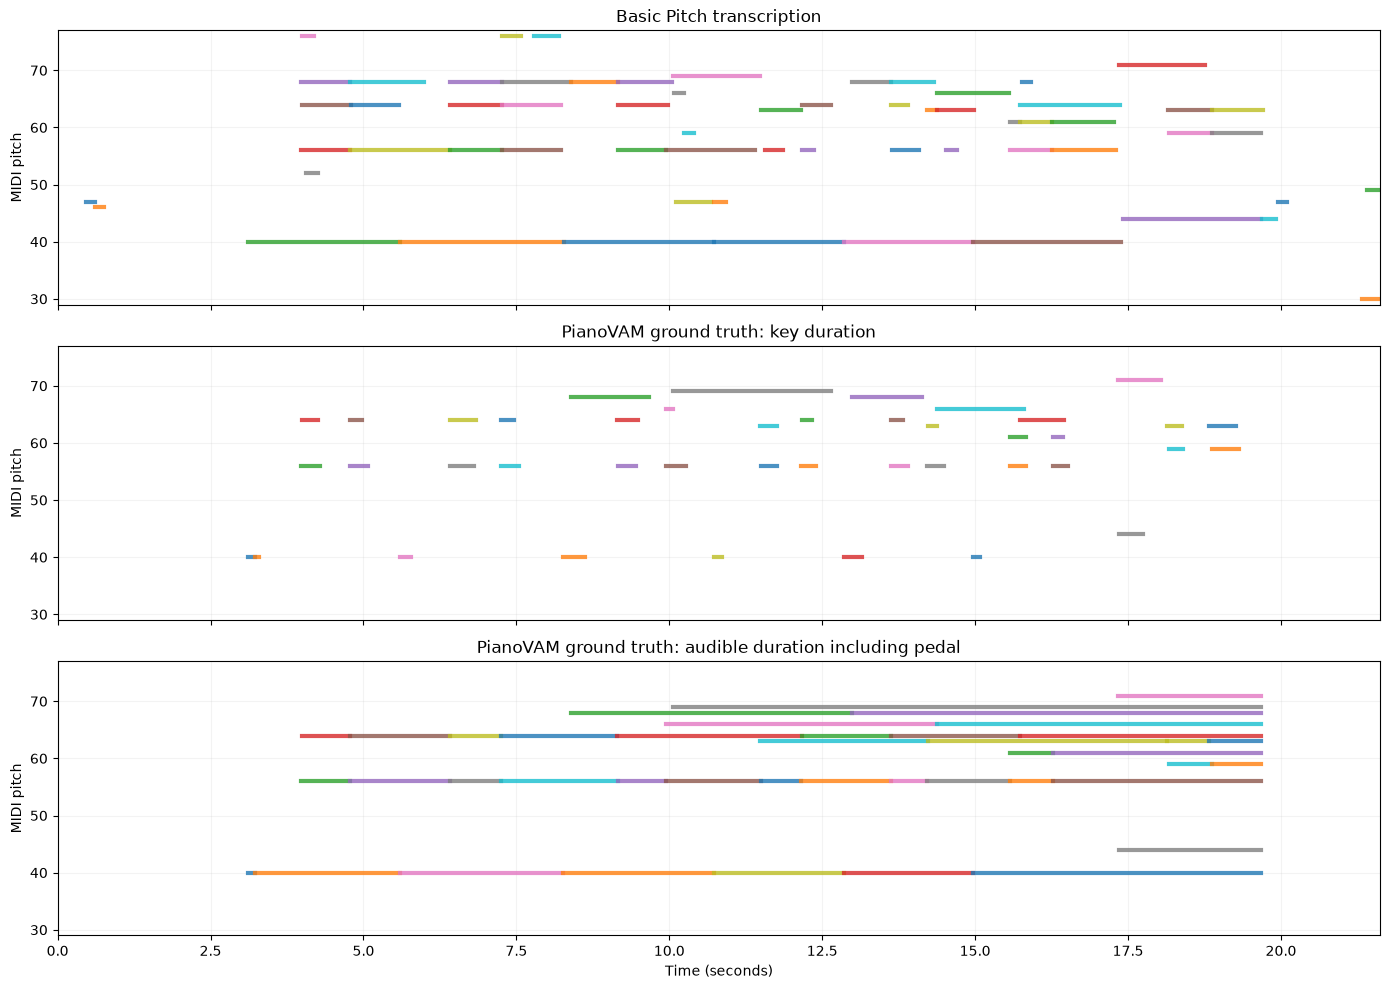

In [9]:
def plot_transcription_piano_roll(ground_truth_notes, predicted_notes, title=None):
    """
    Plot the Basic Pitch transcription and PianoVAM ground truth
    using key duration and audible duration.
    """

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(14, 10),
        sharex=True
    )

    all_pitches = (
        [note["pitch"] for note in predicted_notes]
        + [note["pitch"] for note in ground_truth_notes]
    )

    pitch_min = min(all_pitches) - 1
    pitch_max = max(all_pitches) + 1

    all_times = (
        [note["offset"] for note in predicted_notes]
        + [note["frame_offset"] for note in ground_truth_notes]
    )

    time_max = max(all_times)

    for note in predicted_notes:
        axes[0].plot(
            [note["onset"], note["offset"]],
            [note["pitch"], note["pitch"]],
            linewidth=3,
            alpha=0.8
        )

    axes[0].set_title("Basic Pitch transcription")
    axes[0].set_ylabel("MIDI pitch")
    axes[0].grid(alpha=0.15)

    for note in ground_truth_notes:
        axes[1].plot(
            [note["onset"], note["key_offset"]],
            [note["pitch"], note["pitch"]],
            linewidth=3,
            alpha=0.8
        )

    axes[1].set_title("PianoVAM ground truth: key duration")
    axes[1].set_ylabel("MIDI pitch")
    axes[1].grid(alpha=0.15)

    for note in ground_truth_notes:
        axes[2].plot(
            [note["onset"], note["frame_offset"]],
            [note["pitch"], note["pitch"]],
            linewidth=3,
            alpha=0.8
        )

    axes[2].set_title(
        "PianoVAM ground truth: audible duration including pedal"
    )
    axes[2].set_xlabel("Time (seconds)")
    axes[2].set_ylabel("MIDI pitch")
    axes[2].grid(alpha=0.15)

    for ax in axes:
        ax.set_ylim(pitch_min, pitch_max)
        ax.set_xlim(0, time_max)

    plt.tight_layout()
    plt.show()


plot_transcription_piano_roll(
    ground_truth_notes = reference_notes,
    predicted_notes = predicted_notes,
    title=f"Sample {SELECTED_SAMPLE_ID}: {sample['composer']} - {sample['piece']}",
)

Using the validation set to evaluate the performance of Basic Pitch (with default setting) on PianoVAM, hence try to find optimisation method.

In [10]:
def evaluate_on_pianovam(split_name):
    split_samples = metadata_df[
        (metadata_df["split"] == split_name)
        & (metadata_df["performance_method"] == "Solo")
    ].copy()

    rows = []

    for _, sample in split_samples.iterrows():
        paths = get_sample_paths(sample)
        reference_notes = load_ground_truth_notes(paths["tsv"])
        predicted_notes, _, runtime_seconds = transcribe_audio(paths["audio"])

        transcription_metrics = evaluate_note_transcription(
            reference_notes,
            predicted_notes,
        )
        transcription_output = analyse_transcription_output(
            reference_notes,
            predicted_notes,
        )

        result = {
            "sample_id": sample["sample_id"],
            "record_time": sample["record_time"],
            "composer": sample["composer"],
            "piece": sample["piece"],
            "duration_seconds": sample["duration_seconds"],
        }
        result.update(transcription_metrics)
        result.update(transcription_output)
        result["runtime_seconds"] = runtime_seconds

        rows.append(result)

    return pd.DataFrame(rows)

In [11]:
validation_baseline_df = evaluate_on_pianovam("valid")

validation_output_path = OUTPUT_DIR / "pianovam_validation_baseline.csv"
validation_baseline_df.to_csv(validation_output_path, index=False)

print("Saved:", validation_output_path)
validation_baseline_df

Saved: outputs/phase2_baseline/pianovam_validation_baseline.csv


,sample_id,record_time,composer,piece,duration_seconds,note_precision,note_recall,note_f1,note_precision_no_offset,note_recall_no_offset,...,transcription_extra_notes,transcription_wrong_pitch_notes,transcription_wrong_timing_notes,transcription_wrong_duration_notes,transcription_missing_chords,transcription_extra_chords,transcription_imperfect_chords,transcription_wrong_chords,transcription_output_is_correct,runtime_seconds
0,8,2024-02-15_20-07-54,F. Chopin,"Grande Valse Brillante, Op.18",466.773,0.333027,0.264502,0.294835,0.826367,0.656330,...,91,176,381,439,86,6,1059,52,False,8.801177
1,11,2024-02-15_20-38-23,T. Badarzewska,The Virgin's Prayer,427.968,0.203575,0.192605,0.197938,0.658891,0.623388,...,249,283,457,402,12,16,677,53,False,7.743001
2,16,2024-02-15_21-33-36,L. Beethoven,Piano Sonata No.23 Mvt.3,335.979,0.286170,0.246500,0.264858,0.742830,0.639857,...,83,275,719,640,94,13,560,27,False,4.808352
3,45,2024-03-13_11-54-57,S. Prokofiev,Piano Concerto No.3,1747.733,0.241211,0.179733,0.205982,0.840593,0.626350,...,292,707,1998,2447,725,44,2374,137,False,107.434098
4,58,2024-09-02_12-45-12,J. S. Bach,Italian Concerto Mvt.1,322.717,0.366131,0.332384,0.348442,0.885143,0.803559,...,27,70,256,436,26,3,404,9,False,4.860757
5,61,2024-09-02_15-05-42,Nam Ku Min,Reminiscence,483.961,0.182872,0.264096,0.216104,0.604282,0.872681,...,265,277,95,517,0,50,466,16,False,9.293975
6,63,2024-09-02_15-26-39,Yiruma,Stay in memory,863.959,0.164524,0.255048,0.200021,0.571894,0.886557,...,768,287,223,290,1,189,715,51,False,24.873861
7,67,2024-09-02_19-40-55,M. Ravel,Sonatine Mvt.1,425.380,0.230049,0.325557,0.269594,0.623080,0.881760,...,274,158,87,381,2,63,301,18,False,6.482390
8,71,2024-09-02_23-22-31,Debussy,Images 3. Mouvement,389.410,0.210420,0.230050,0.219798,0.622703,0.680793,...,165,366,761,881,27,22,613,36,False,6.912821


standard metrics to evaluation the transcription

In [12]:
def summarise_amt_results(results_df):
    metric_columns = [
        "note_precision",
        "note_recall",
        "note_f1",
        "note_precision_no_offset",
        "note_recall_no_offset",
        "note_f1_no_offset",
        "note_average_overlap",
        "runtime_seconds",
    ]

    summary = pd.DataFrame({
        "mean": results_df[metric_columns].mean(),
        "median": results_df[metric_columns].median(),
        "std": results_df[metric_columns].std(),
        "min": results_df[metric_columns].min(),
        "max": results_df[metric_columns].max(),
    })

    return summary


validation_amt_summary = summarise_amt_results(validation_baseline_df)
validation_amt_summary

,mean,median,std,min,max
note_precision,0.246442,0.230049,0.068542,0.164524,0.366131
note_recall,0.254497,0.255048,0.051709,0.179733,0.332384
note_f1,0.246397,0.219798,0.051716,0.197938,0.348442
note_precision_no_offset,0.708420,0.658891,0.117454,0.571894,0.885143
note_recall_no_offset,0.741253,0.680793,0.117396,0.623388,0.886557
note_f1_no_offset,0.712220,0.714094,0.058641,0.640648,0.842380
note_average_overlap,0.896231,0.911669,0.041705,0.826032,0.943989
runtime_seconds,20.134492,7.743001,33.302708,4.808352,107.434098


Inspect the detailed results of the whole validation set

In [13]:
analysis_columns = [
    "sample_id",
    "composer",
    "piece",
    "duration_seconds",
    "reference_notes",
    "predicted_notes",
    "note_precision",
    "note_recall",
    "note_f1",
    "note_f1_no_offset",
    "note_average_overlap",
    "transcription_missing_notes",
    "transcription_extra_notes",
    "transcription_wrong_pitch_notes",
    "transcription_wrong_timing_notes",
    "transcription_wrong_duration_notes",
]

validation_analysis_table = validation_baseline_df[analysis_columns].sort_values(
    "note_f1_no_offset"
)
validation_analysis_table

,sample_id,composer,piece,duration_seconds,reference_notes,predicted_notes,note_precision,note_recall,note_f1,note_f1_no_offset,note_average_overlap,transcription_missing_notes,transcription_extra_notes,transcription_wrong_pitch_notes,transcription_wrong_timing_notes,transcription_wrong_duration_notes
1,11,T. Badarzewska,The Virgin's Prayer,427.968,3489,3301,0.203575,0.192605,0.197938,0.640648,0.943989,302,249,283,457,402
8,71,Debussy,Images 3. Mouvement,389.410,3634,3973,0.210420,0.230050,0.219798,0.650454,0.845577,304,165,366,761,881
2,16,L. Beethoven,Piano Sonata No.23 Mvt.3,335.979,3643,3138,0.286170,0.246500,0.264858,0.687509,0.918171,291,83,275,719,640
6,63,Yiruma,Stay in memory,863.959,3764,5835,0.164524,0.255048,0.200021,0.695281,0.935191,5,768,287,223,290
5,61,Nam Ku Min,Reminiscence,483.961,2749,3970,0.182872,0.264096,0.216104,0.714094,0.914317,26,265,277,95,517
3,45,S. Prokofiev,Piano Concerto No.3,1747.733,15651,11662,0.241211,0.179733,0.205982,0.717827,0.826032,1190,292,707,1998,2447
7,67,M. Ravel,Sonatine Mvt.1,425.380,1886,2669,0.230049,0.325557,0.269594,0.730187,0.911522,25,274,158,87,381
0,8,F. Chopin,"Grande Valse Brillante, Op.18",466.773,5482,4354,0.333027,0.264502,0.294835,0.731598,0.911669,280,91,176,381,439
4,58,J. S. Bach,Italian Concerto Mvt.1,322.717,2810,2551,0.366131,0.332384,0.348442,0.842380,0.859609,130,27,70,256,436


Case studies for representative cases:
- lowest no-offset F1: weakest overall pitch/onset transcription --- sample id = 11
- lowest precision: most severe extra-note tendency --- sample id = 63
- lowest recall: most severe missed-note tendency --- sample id = 45
- highest no-offset F1: a strong baseline example --- sample id = 58

In [14]:
def run_case_study(sample_id):
    sample = metadata_df[metadata_df["sample_id"] == sample_id].iloc[0]
    paths = get_sample_paths(sample)

    reference_notes = load_ground_truth_notes(paths["tsv"])
    predicted_notes, _, _ = transcribe_audio(paths["audio"])

    plot_transcription_piano_roll(
        reference_notes,
        predicted_notes,
        title=f"Sample {sample_id}: {sample['composer']} - {sample['piece']}",
    )

    metrics = evaluate_note_transcription(reference_notes, predicted_notes)
    transcription_output = analyse_transcription_output(reference_notes, predicted_notes)

    result = {}
    result.update(metrics)
    result.update(transcription_output)

    return pd.Series(result)

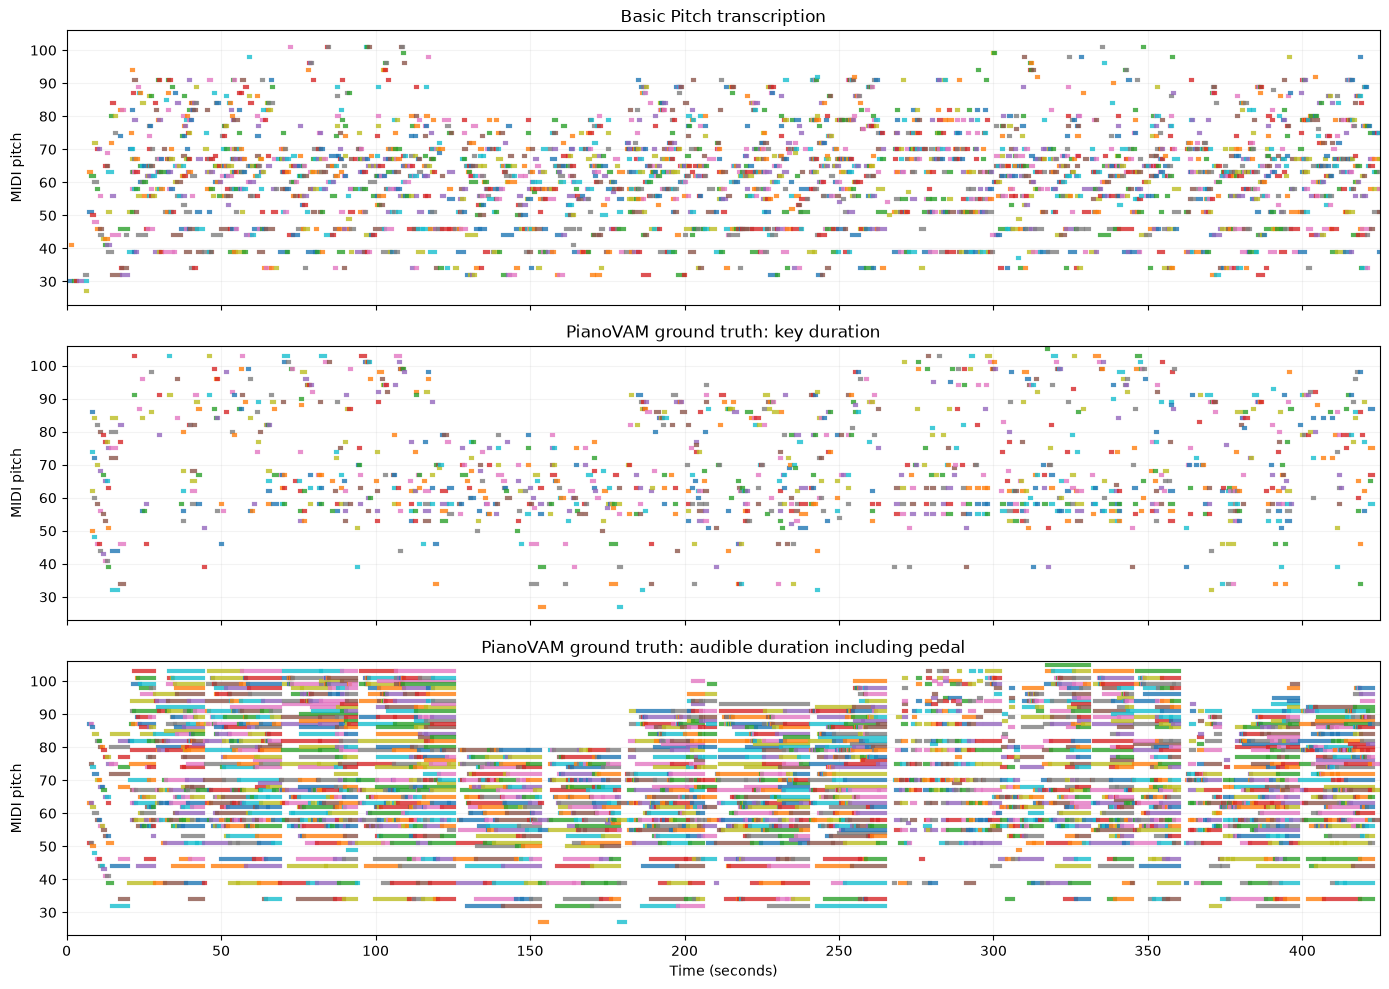

note_precision                        0.203575
note_recall                           0.192605
note_f1                               0.197938
note_precision_no_offset              0.658891
note_recall_no_offset                 0.623388
note_f1_no_offset                     0.640648
note_average_overlap                  0.943989
reference_notes                           3489
predicted_notes                           3301
note_count_difference                     -188
transcription_missing_notes                302
transcription_extra_notes                  249
transcription_wrong_pitch_notes            283
transcription_wrong_timing_notes           457
transcription_wrong_duration_notes         402
transcription_missing_chords                12
transcription_extra_chords                  16
transcription_imperfect_chords             677
transcription_wrong_chords                  53
transcription_output_is_correct          False
dtype: object

In [15]:
run_case_study("11")

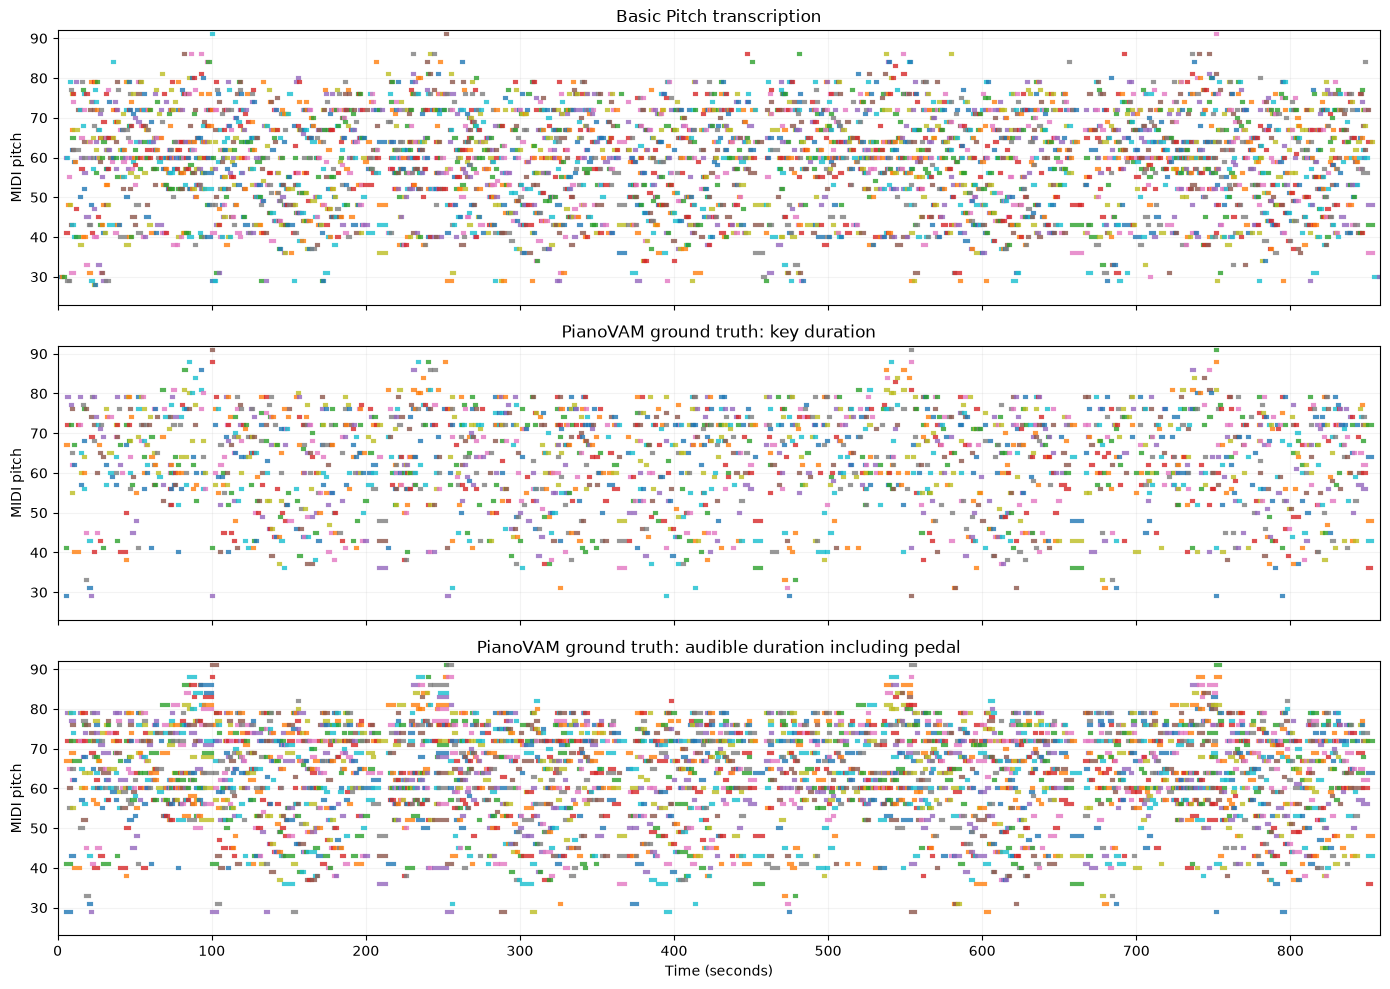

note_precision                        0.164524
note_recall                           0.255048
note_f1                               0.200021
note_precision_no_offset              0.571894
note_recall_no_offset                 0.886557
note_f1_no_offset                     0.695281
note_average_overlap                  0.935191
reference_notes                           3764
predicted_notes                           5835
note_count_difference                     2071
transcription_missing_notes                  5
transcription_extra_notes                  768
transcription_wrong_pitch_notes            287
transcription_wrong_timing_notes           223
transcription_wrong_duration_notes         290
transcription_missing_chords                 1
transcription_extra_chords                 189
transcription_imperfect_chords             715
transcription_wrong_chords                  51
transcription_output_is_correct          False
dtype: object

In [16]:
run_case_study("63")

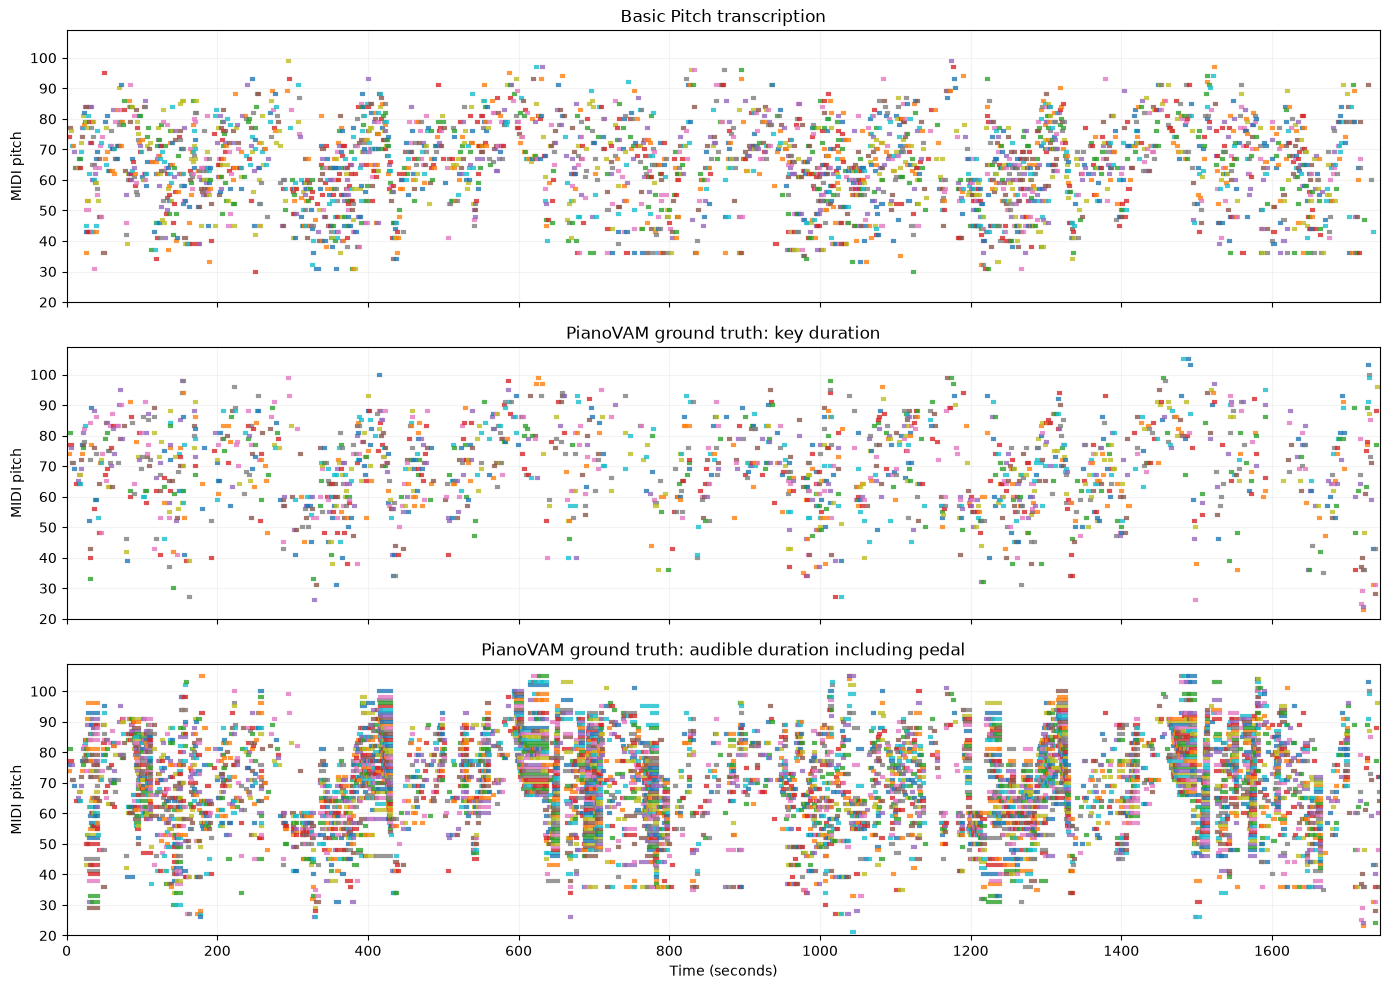

note_precision                        0.241211
note_recall                           0.179733
note_f1                               0.205982
note_precision_no_offset              0.840593
note_recall_no_offset                  0.62635
note_f1_no_offset                     0.717827
note_average_overlap                  0.826032
reference_notes                          15651
predicted_notes                          11662
note_count_difference                    -3989
transcription_missing_notes               1190
transcription_extra_notes                  292
transcription_wrong_pitch_notes            707
transcription_wrong_timing_notes          1998
transcription_wrong_duration_notes        2447
transcription_missing_chords               725
transcription_extra_chords                  44
transcription_imperfect_chords            2374
transcription_wrong_chords                 137
transcription_output_is_correct          False
dtype: object

In [17]:
run_case_study("45")

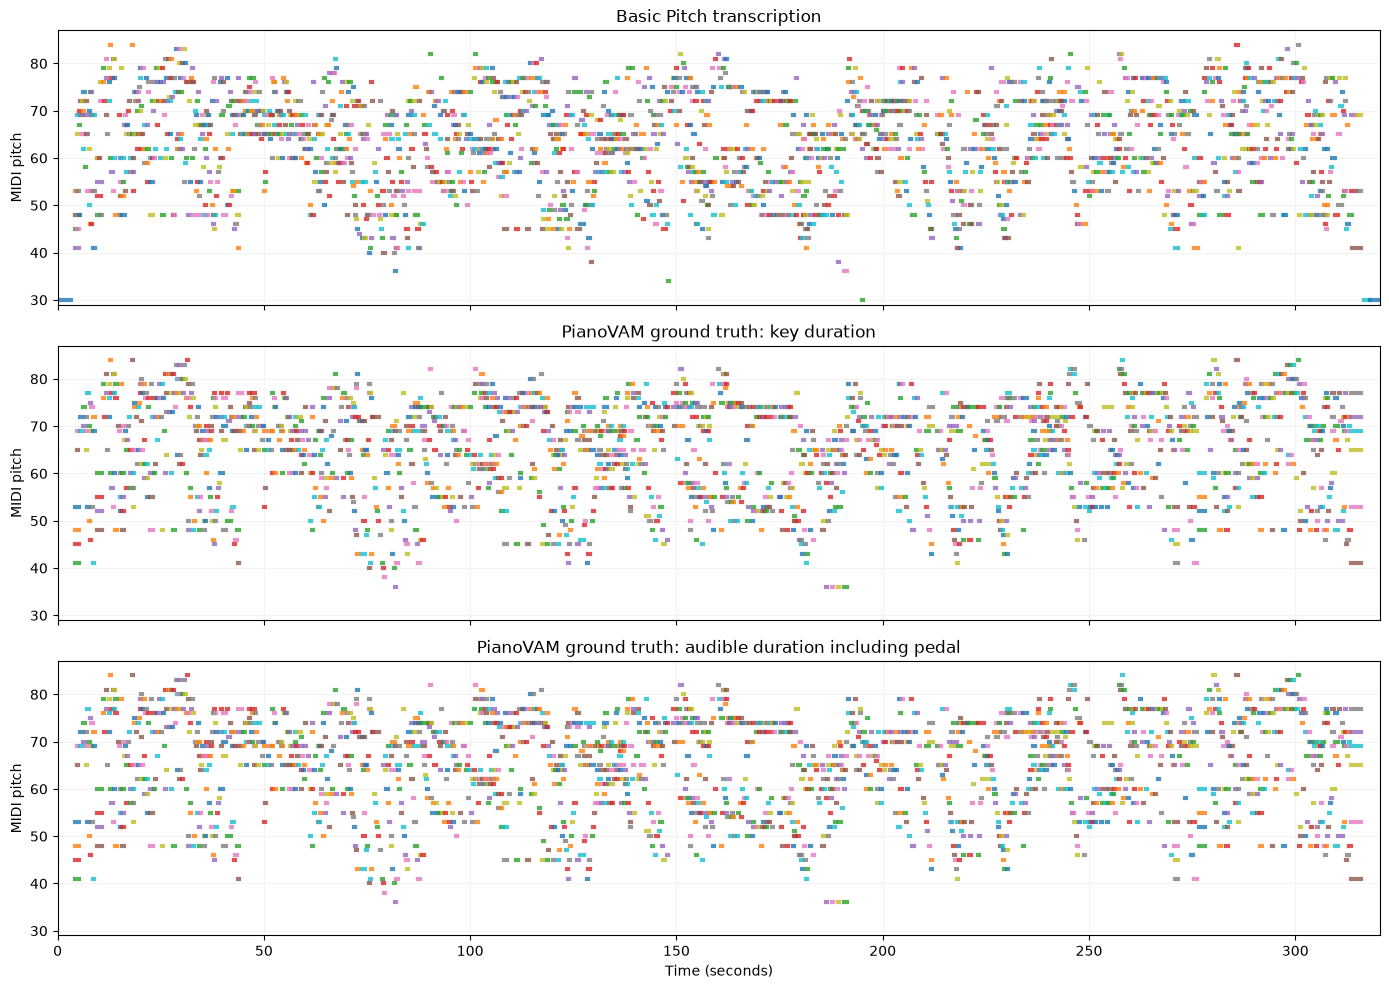

note_precision                        0.366131
note_recall                           0.332384
note_f1                               0.348442
note_precision_no_offset              0.885143
note_recall_no_offset                 0.803559
note_f1_no_offset                      0.84238
note_average_overlap                  0.859609
reference_notes                           2810
predicted_notes                           2551
note_count_difference                     -259
transcription_missing_notes                130
transcription_extra_notes                   27
transcription_wrong_pitch_notes             70
transcription_wrong_timing_notes           256
transcription_wrong_duration_notes         436
transcription_missing_chords                26
transcription_extra_chords                   3
transcription_imperfect_chords             404
transcription_wrong_chords                   9
transcription_output_is_correct          False
dtype: object

In [18]:
run_case_study("58")

Interpretation:

## post-processing experiments

Potential modifications:

- remove predictions before the likely performance start;
- tune onset and frame thresholds;
- tune minimum note length;
- reduce short isolated notes likely to be noise;
- investigate pedal-aware offset handling;

Evaluated using the same validation set, same AMT metrics and case studies.